# Tableau - Graph - Geo
- https://help.tableau.com/current/pro/desktop/en-us/maps.htm
- https://help.tableau.com/current/pro/desktop/en-us/maps_howto_simple.htm
- https://help.tableau.com/current/pro/desktop/en-us/maps_build.htm
- https://help.tableau.com/current/pro/desktop/en-us/maps_build2.htm
- https://help.tableau.com/current/pro/desktop/en-us/maps_options.htm

## Simple Point Map
- Navigate to a worksheet.
- In the Data pane, open the Location folder and double-click State.
- A map view is automatically created because the State field is a geographic field. To learn more about geographic fields and how to create them
- From the Orders table in the Data pane, drag Sales to Size on the Marks card.
- The data points on the map update to show the amount of sales proportionally.
- Select Maps > Background Layers.
- In the Background pane, click the Style drop-down and select Normal.
- Under Background Map Layers, clear Country/Region Names. The background map updates with the new settings.

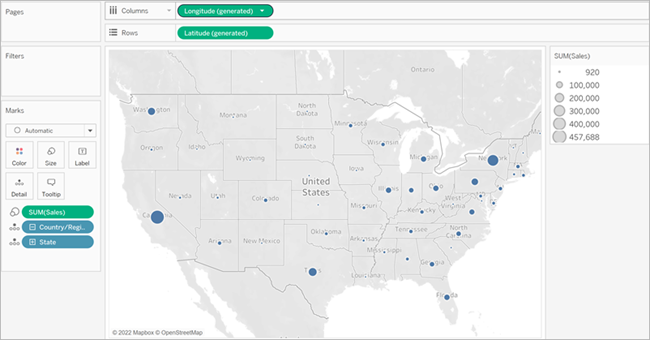

## Simple Polygon Filled Map
- Navigate to a new worksheet.
- In the Data pane, open the Location folder and double-click State.
- A map view is automatically created.
- On the Marks card, click the Mark Type drop-down and select Map. : The map view updates to a filled (polygon) map.
- From the Orders table in the Data pane, drag Sales to Color on the Marks card.
- The polygons on the map update to show the amount of sales using color.

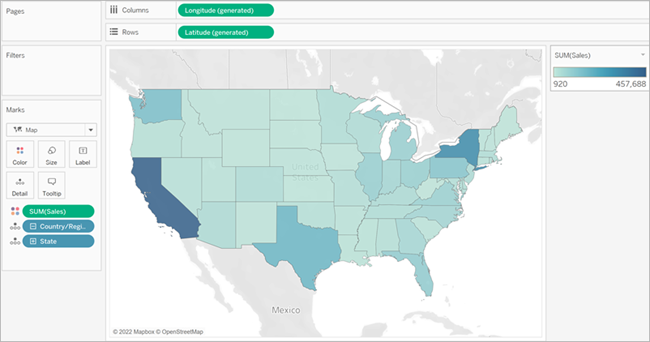

## Python 

In [23]:
# Data
import numpy as np
import pandas as pd
import datetime as dt
import plotly.express as px
url1 = 'https://raw.githubusercontent.com/dupadhyaya/piit/refs/heads/main/data/superstore_orders.csv'
print(url1)
sales = pd.read_csv(url1)
sales.shape

https://raw.githubusercontent.com/dupadhyaya/piit/refs/heads/main/data/superstore_orders.csv


(10194, 21)

In [24]:
sales.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [25]:
sales = sales.rename(columns ={'State/Province':'State'})

In [26]:
sales.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [27]:
state_sales = (sales.groupby('State', as_index=False).agg(Sales=('Sales', 'sum'))
)
state_sales.head()

,State,Sales
0,Alabama,19510.640
1,Alberta,11460.186
2,Arizona,35282.001
3,Arkansas,11678.130
4,British Columbia,2763.200


In [28]:
state_abbrev = {    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT',
    'Delaware': 'DE', 'District of Columbia': 'DC', 'Florida': 'FL',
    'Georgia': 'GA', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN',
    'Iowa': 'IA', 'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA',
    'Maine': 'ME', 'Maryland': 'MD', 'Massachusetts': 'MA',
    'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE',
    'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ',
    'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC',
    'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK',
    'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI',
    'South Carolina': 'SC', 'South Dakota': 'SD', 'Tennessee': 'TN',
    'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA',
    'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI',
    'Wyoming': 'WY'}
state_sales['State_Code'] = state_sales['State'].map(state_abbrev)
state_sales.head()

,State,Sales,State_Code
0,Alabama,19510.640,AL
1,Alberta,11460.186,NaN
2,Arizona,35282.001,AZ
3,Arkansas,11678.130,AR
4,British Columbia,2763.200,NaN


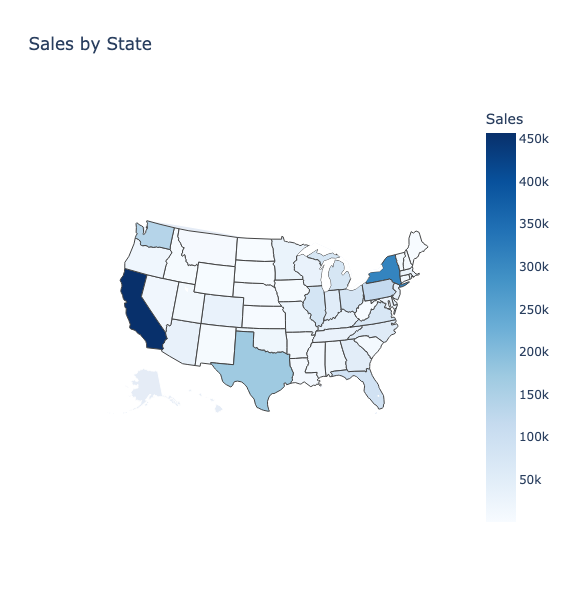

In [29]:
fig = px.choropleth( state_sales,   locations='State_Code',  \
    locationmode='USA-states', color='Sales',    scope='usa',hover_name='State',
    color_continuous_scale='Blues',  title='Sales by State')
fig.update_layout(   width=1000,   height=600 )
fig.show();

In [18]:
## City Level
city_sales = ( sales.groupby(['City', 'State'], as_index=False)  .agg(Sales=('Sales', 'sum'))
)
city_sales.head()

,City,State,Sales
0,Aberdeen,South Dakota,25.500
1,Abilene,Texas,1.392
2,Akron,Ohio,2729.986
3,Albuquerque,New Mexico,2220.160
4,Alexandria,Virginia,5519.570


In [20]:
#fig = px.scatter_geo(    city_sales,    lat='Latitude',   lon='Longitude',   size='Sales', hover_name='City',    color='Sales',   scope='usa',    title='City-wise Sales Bubble Map'
)
#fig.show()

IndentationError: unexpected indent (916228918.py, line 2)